In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [ ]:
import pycbc
from pycbc.waveform import get_td_waveform
from modules.gw_utils import Planck_window_LAL, planck_taper

import numpy as np
import multiprocessing
import matplotlib.pyplot as plt

In [26]:
def generate_fd_waveform(params, f_lower, delta_t):
    q = params['q']
    chi = params['chi']
    M_total = 40.0
    m2 = M_total / (1 + q)
    m1 = q * M_total / (1 + q)


    hp, hc = get_td_waveform(approximant='SEOBNRv4_opt',
                                mass1=m1, mass2=m2,
                                spin1z=chi, spin2z=chi,
                                delta_t=delta_t,
                                f_lower=f_lower)
    
    return hp, hc

In [ ]:
def process_waveform(params, f_lower, delta_t):
    
    hp, hc = generate_fd_waveform(params, f_lower, delta_t)
    
    return hp, hc

q_vals = np.linspace(1, 10, 50)
chi_vals = np.linspace(-1.0, 1.0, 50)
param_grid_q, param_grid_chi = np.meshgrid(q_vals, chi_vals)
params_list = [{'q': q, 'chi': chi} for q, chi in zip(param_grid_q.flatten(), param_grid_chi.flatten())]

f_lower = 15.0
delta_t = 1/4096

args_for_starmap = [(p, f_lower, delta_t) for p in params_list]

num_processes = multiprocessing.cpu_count()
with multiprocessing.Pool(processes=num_processes) as pool:
    results = pool.starmap(process_waveform, args_for_starmap)

In [17]:
list_of_max_freqs = []

for i in range(len(results)):
    hp, hc = results[i]
    freq = pycbc.waveform.utils.frequency_from_polarizations(hp, hc)
    list_of_max_freqs.append(max(freq))

print(f"{min(list_of_max_freqs):.4f}")

262.9345


In [18]:
print(f"{max(list_of_max_freqs):.4f}")

2047.5517


# Get max frequency across parameter space

In [10]:
from pycbc.pnutils import get_final_freq

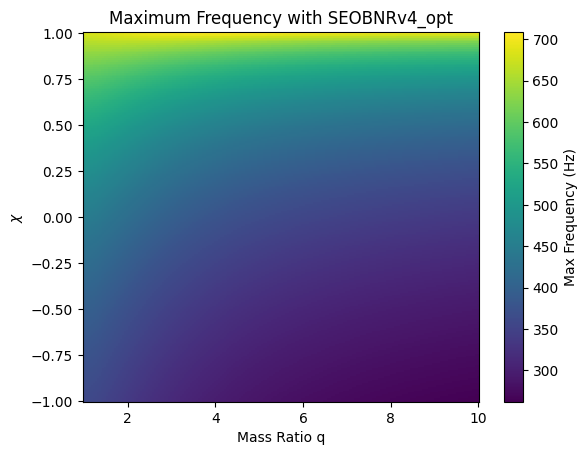

In [11]:
approx = 'SEOBNRv4_opt'

def find_max_freq(params):
    q = params['q']
    chi = params['chi']
    M_total = 40.0
    m2 = M_total / (1 + q)
    m1 = q * M_total / (1 + q)

    max_freq = get_final_freq(approx, m1, m2, chi, chi)

    return max_freq

q_vals = np.linspace(1, 10, 200)
chi_vals = np.linspace(-1.0, 1.0, 200)

param_grid_q, param_grid_chi = np.meshgrid(q_vals, chi_vals)
params_list = [{'q': q, 'chi': chi} for q, chi in zip(param_grid_q.flatten(), param_grid_chi.flatten())]

num_processes = multiprocessing.cpu_count()
with multiprocessing.Pool(processes=num_processes) as pool:
    results = pool.map(find_max_freq, params_list)

plt.pcolormesh(param_grid_q, param_grid_chi, np.array(results).reshape(param_grid_q.shape), shading='auto')
plt.colorbar(label='Max Frequency (Hz)')
plt.xlabel('Mass Ratio q')
plt.ylabel('$\chi$')
plt.title(f'Maximum Frequency with {approx}')
plt.show()

In [12]:
min(results), max(results)

(array(261.95512449), array(708.74413507))

In [13]:
idx = np.where(np.array(results) == max(results))[0][0]

In [14]:
params_list[idx]

{'q': np.float64(3.9396984924623117), 'chi': np.float64(1.0)}

In [15]:
find_max_freq(params_list[idx])

array(708.74413507)

# Generating frequency evolution 

In [3]:
def generate_waveform(params, f_lower, delta_t):
    q = params['q']
    chi = params['chi']
    M_total = 40.0
    m2 = M_total / (1 + q)
    m1 = q * M_total / (1 + q)


    hp, hc = get_td_waveform(approximant='SEOBNRv4_opt',
                                mass1=m1, mass2=m2,
                                spin1z=chi, spin2z=chi,
                                delta_t=delta_t,
                                f_lower=f_lower)
    
    return hp, hc

In [4]:
f_lower = 15.0
delta_t = 1/4096

test_params = {'q': 1.0, 'chi': 1.0}

hp, hc = generate_waveform(test_params, f_lower, delta_t)
f = pycbc.waveform.utils.frequency_from_polarizations(hp, hc)

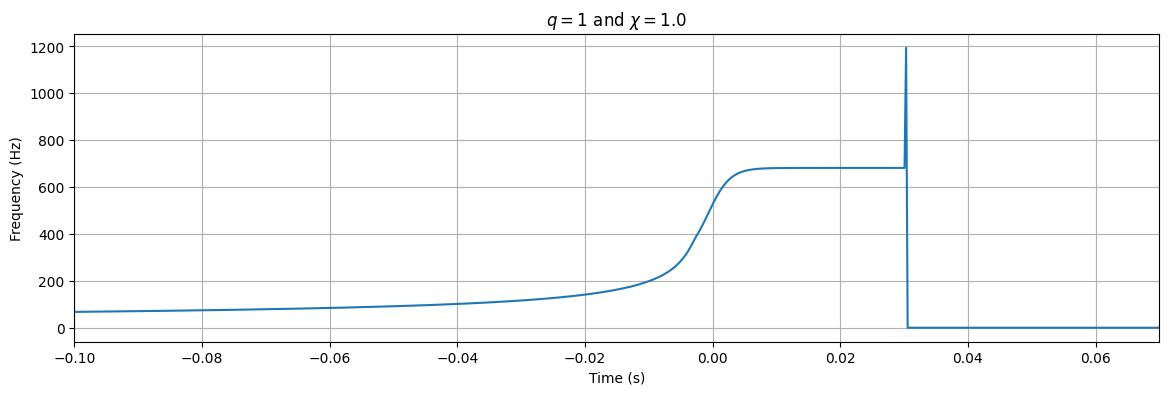

In [6]:
plt.figure(figsize=(14, 4))
plt.plot(f.sample_times, f)
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title(rf'$q = 1$ and $\chi = 1.0$')
plt.xlim(-0.1, 0.07)
plt.grid()
plt.show()